# Notebook 7 — Classification for CA Professionals

**Goal:** Predict a **category** — for example "will this loan default — Yes or No?"

**You will learn:**
1. What classification is and how it differs from regression
2. Preparing the data (X / y, encoding, train/test split)
3. Logistic Regression — a simple, interpretable classifier
4. Decision Tree — a model your manager can read
5. Measuring quality: Accuracy, Confusion Matrix, Precision/Recall
6. Which features matter most
7. A short mini-project on loan default

> The dataset is `data/loans.csv` — 300 loans with a known `Defaulted` (1/0) flag.

---

## 1. Classification vs Regression

| Question                                 | Type            |
|------------------------------------------|-----------------|
| "What will next month's revenue be?"     | Regression (number) |
| "Will this client default? Yes / No"     | Classification (category) |
| "Is this transaction fraudulent?"        | Classification |
| "Which risk bucket does the customer fall in: Low/Med/High?" | Classification (3 classes) |

The data preparation steps are the **same**. Only the model and the evaluation metrics change.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

loans = pd.read_csv("data/loans.csv")
print("Shape :", loans.shape)
print("Default rate :", f"{loans['Defaulted'].mean()*100:.1f}%")
loans.head()

Shape : (300, 10)
Default rate : 41.3%


,Loan_ID,Customer,Loan_Amount,Tenure_Months,Interest_Rate,Annual_Income,Credit_Score,Has_Collateral,Sector,Defaulted
0,L2000,Cust_000,100000,36,13.78,180000,300,No,Trade,1
1,L2001,Cust_001,500000,12,11.59,360000,451,Yes,Service,1
2,L2002,Cust_002,1000000,12,13.08,180000,521,Yes,Service,0
3,L2003,Cust_003,100000,60,9.83,180000,403,Yes,Trade,0
4,L2004,Cust_004,100000,120,8.17,180000,750,Yes,Personal,0


## 2. Preparing the data

Two preparation steps:

1. **Encode** any text column into numbers (so the model can read it).
2. **Split** into a feature matrix `X` and a target vector `y`.

In [2]:
# Encode text columns
loans["Has_Coll_Code"] = loans["Has_Collateral"].map({"Yes": 1, "No": 0})

# One-hot encode the Sector column
sector_dummies = pd.get_dummies(loans["Sector"], prefix="Sec").astype(int)
data = pd.concat([loans, sector_dummies], axis=1)

# Pick the features we will use
feature_cols = [
    "Loan_Amount", "Tenure_Months", "Interest_Rate",
    "Annual_Income", "Credit_Score", "Has_Coll_Code",
] + list(sector_dummies.columns)

X = data[feature_cols]
y = data["Defaulted"]

X.head()

,Loan_Amount,Tenure_Months,Interest_Rate,Annual_Income,Credit_Score,Has_Coll_Code,Sec_Agriculture,Sec_Manufacturing,Sec_Personal,Sec_Service,Sec_Trade
0,100000,36,13.78,180000,300,0,0,0,0,0,1
1,500000,12,11.59,360000,451,1,0,0,0,1,0
2,1000000,12,13.08,180000,521,1,0,0,0,1,0
3,100000,60,9.83,180000,403,1,0,0,0,0,1
4,100000,120,8.17,180000,750,1,0,0,1,0,0


In [3]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_tr), "  Test:", len(X_te))
print("Default rate (train):", f"{y_tr.mean()*100:.1f}%")
print("Default rate (test) :", f"{y_te.mean()*100:.1f}%")

Train: 225   Test: 75
Default rate (train): 41.3%
Default rate (test) : 41.3%


## 3. Logistic Regression — the simplest classifier

Despite the name "regression", logistic regression is a **classification** model. It outputs a probability between 0 and 1 — anything above 0.5 means "predict default".

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scaling helps logistic regression converge cleanly
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_tr_s, y_tr)

print("Training accuracy :", round(logit.score(X_tr_s, y_tr), 3))
print("Test accuracy     :", round(logit.score(X_te_s, y_te), 3))

Training accuracy : 0.778
Test accuracy     : 0.733


## 4. Confusion Matrix — where the model is right and wrong

The confusion matrix is the heart of classification evaluation:

```
                  Predicted: No   Predicted: Yes
Actual: No   →    TN  (good)       FP  (false alarm)
Actual: Yes  →    FN  (missed!)    TP  (caught)
```

| Metric    | Formula              | Meaning                              |
|-----------|----------------------|--------------------------------------|
| Accuracy  | (TP+TN)/all          | overall % correct                    |
| Precision | TP / (TP+FP)         | "of those predicted default, % correct" |
| Recall    | TP / (TP+FN)         | "of actual defaults, % caught"       |

For loan default the **most expensive mistake** is FN — missing a real defaulter. So we care most about **Recall**.

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = logit.predict(X_te_s)

cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix:")
print(cm)
print()
print(classification_report(y_te, y_pred, target_names=["No Default","Default"]))

Confusion matrix:
[[37  7]
 [13 18]]

              precision    recall  f1-score   support

  No Default       0.74      0.84      0.79        44
     Default       0.72      0.58      0.64        31

    accuracy                           0.73        75
   macro avg       0.73      0.71      0.72        75
weighted avg       0.73      0.73      0.73        75



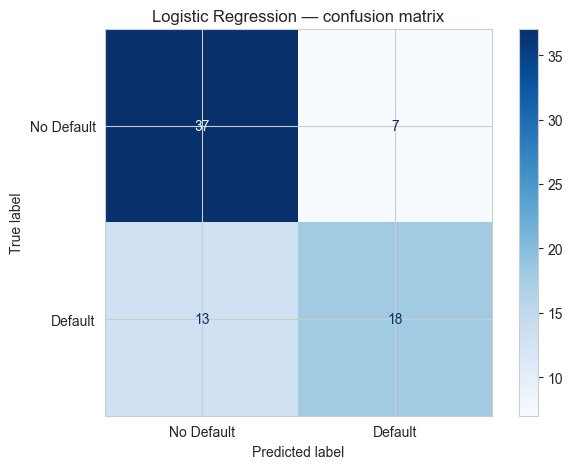

In [6]:
ConfusionMatrixDisplay(cm, display_labels=["No Default","Default"]).plot(cmap="Blues")
plt.title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.show()

### Practice 1
Compute the **accuracy** by hand from the confusion matrix above:

`accuracy = (TN + TP) / total`

Print the result and check it matches `accuracy_score(y_te, y_pred)`.

In [7]:
# Your turn:

<details><summary>Show solution</summary>

In [8]:
from sklearn.metrics import accuracy_score
tn, fp, fn, tp = cm.ravel()
print(f"By hand : {(tn+tp)/(tn+fp+fn+tp):.3f}")
print(f"Sklearn : {accuracy_score(y_te, y_pred):.3f}")

By hand : 0.733
Sklearn : 0.733


</details>

## 5. Decision Tree — a model you can read

A Decision Tree builds a flowchart of yes/no questions. Easy to explain to non-technical clients.

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_tr, y_tr)   # trees don't need scaling

print("Train accuracy:", round(tree.score(X_tr, y_tr), 3))
print("Test  accuracy:", round(tree.score(X_te, y_te), 3))

Train accuracy: 0.764
Test  accuracy: 0.747


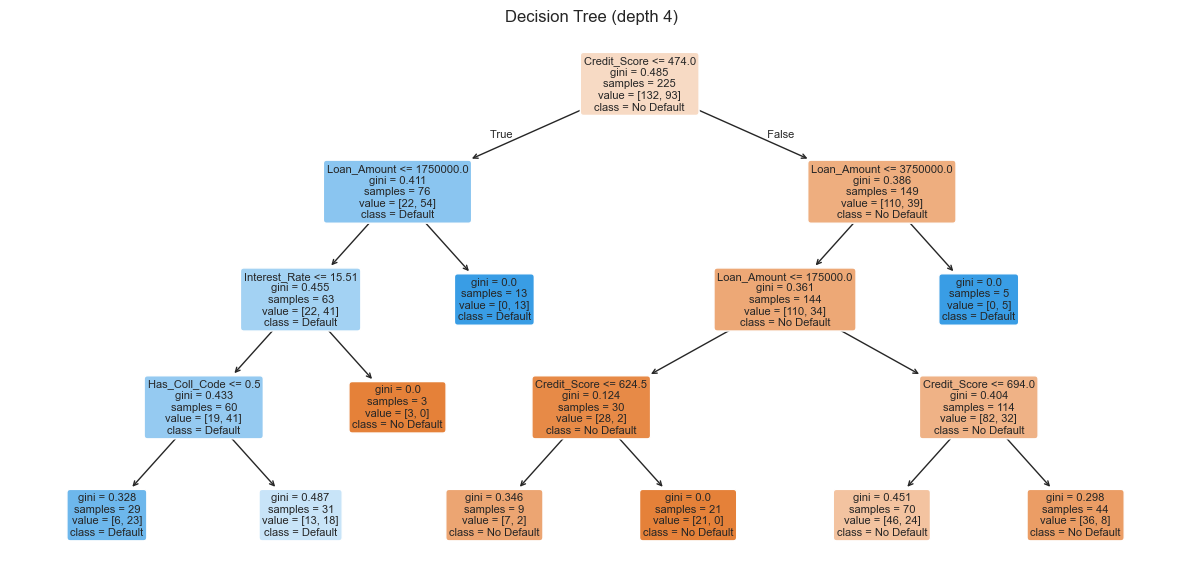

In [10]:
plt.figure(figsize=(15, 7))
plot_tree(tree,
          feature_names=X.columns,
          class_names=["No Default","Default"],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree (depth 4)")
plt.show()

### Practice 2
Build another Decision Tree with `max_depth=2` (a very shallow tree). Print its train and test accuracy. Is it better or worse than the depth-4 tree?

In [11]:
# Your turn:

<details><summary>Show solution</summary>

In [12]:
t2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_tr, y_tr)
print("depth=2 train:", round(t2.score(X_tr, y_tr), 3))
print("depth=2 test :", round(t2.score(X_te, y_te), 3))

depth=2 train: 0.751
depth=2 test : 0.72


</details>

## 6. Which features matter most?

A Decision Tree (and other tree models) can tell us which inputs were most useful.

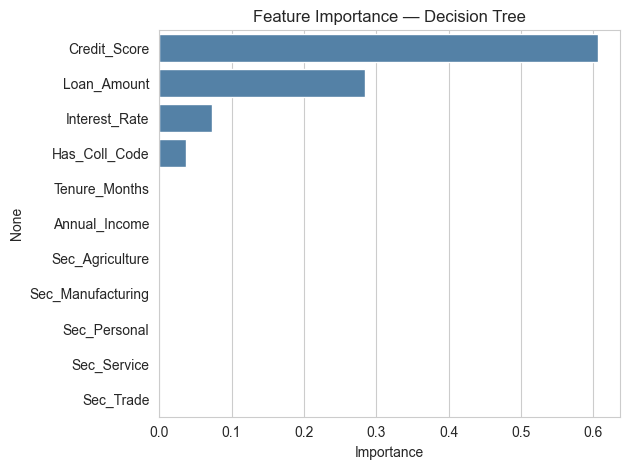

Credit_Score         0.607
Loan_Amount          0.284
Interest_Rate        0.073
Has_Coll_Code        0.037
Tenure_Months        0.000
Annual_Income        0.000
Sec_Agriculture      0.000
Sec_Manufacturing    0.000
Sec_Personal         0.000
Sec_Service          0.000
Sec_Trade            0.000
dtype: float64

In [13]:
imp = pd.Series(tree.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False)

sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp.round(3)

## 7. Predicting for a new loan application

Given a brand-new application, the model tells us the **probability of default**.

In [14]:
new_loan = pd.DataFrame({
    "Loan_Amount":   [1500000],
    "Tenure_Months": [36],
    "Interest_Rate": [12.5],
    "Annual_Income": [600000],
    "Credit_Score":  [610],
    "Has_Coll_Code": [0],            # no collateral
    "Sec_Agriculture":[0], "Sec_Manufacturing":[0],
    "Sec_Personal":[1],  "Sec_Service":[0], "Sec_Trade":[0],
})

# Make sure the columns match X exactly
new_loan = new_loan[X.columns]

prob = tree.predict_proba(new_loan)[0, 1]
print(f"Default probability : {prob*100:.1f}%")
print("Decision           :", "REJECT / High risk" if prob > 0.5 else "Approve")

Default probability : 34.3%
Decision           : Approve


## 8. Mini-Project — Build your own default-risk classifier

Steps:

1. Re-load `data/loans.csv`.
2. Encode `Has_Collateral` and one-hot encode `Sector`.
3. Build `X` and `y` (target = `Defaulted`).
4. Split 70 / 30 with `random_state=1`.
5. Train **both** a `LogisticRegression` (with scaling) and a `DecisionTreeClassifier(max_depth=5)`.
6. Print test accuracy and the **classification report** for each.
7. Plot the confusion matrix for the better model.
8. Write a one-line conclusion: which model would you pick and why?

In [15]:
# Your code here

<details><summary>Show solution</summary>


=== LogReg ===
Accuracy: 0.656
              precision    recall  f1-score   support

      No Def       0.71      0.70      0.70        53
         Def       0.58      0.59      0.59        37

    accuracy                           0.66        90
   macro avg       0.65      0.65      0.65        90
weighted avg       0.66      0.66      0.66        90


=== Tree ===
Accuracy: 0.644
              precision    recall  f1-score   support

      No Def       0.69      0.72      0.70        53
         Def       0.57      0.54      0.56        37

    accuracy                           0.64        90
   macro avg       0.63      0.63      0.63        90
weighted avg       0.64      0.64      0.64        90



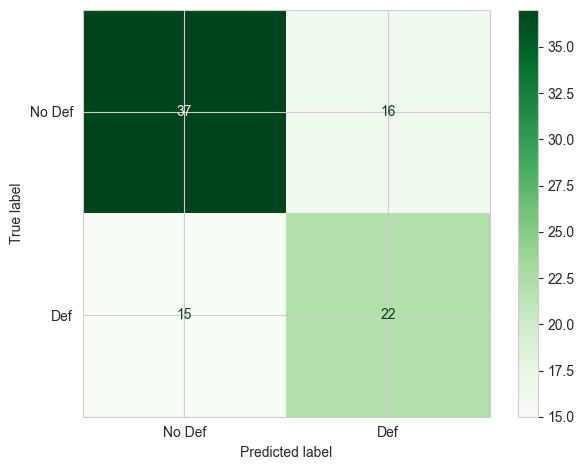


Conclusion: pick the model with higher *recall* on Default class —
missing a real defaulter (FN) costs more than a false alarm.


In [16]:
df = pd.read_csv("data/loans.csv")
df["Has_Coll_Code"] = df["Has_Collateral"].map({"Yes":1,"No":0})
dum = pd.get_dummies(df["Sector"], prefix="Sec").astype(int)
df = pd.concat([df, dum], axis=1)

feat = ["Loan_Amount","Tenure_Months","Interest_Rate","Annual_Income",
        "Credit_Score","Has_Coll_Code"] + list(dum.columns)
X, y = df[feat], df["Defaulted"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)

lr = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
dt = DecisionTreeClassifier(max_depth=5, random_state=1).fit(X_tr, y_tr)

for name, m, Xt in [("LogReg", lr, X_te_s), ("Tree", dt, X_te)]:
    p = m.predict(Xt)
    print(f"\n=== {name} ===")
    print("Accuracy:", round(m.score(Xt, y_te), 3))
    print(classification_report(y_te, p, target_names=["No Def","Def"]))

# pick the better one to show CM
better = lr if lr.score(X_te_s, y_te) >= dt.score(X_te, y_te) else dt
cm = confusion_matrix(y_te, better.predict(X_te_s if better is lr else X_te))
ConfusionMatrixDisplay(cm, display_labels=["No Def","Def"]).plot(cmap="Greens")
plt.tight_layout(); plt.show()

print("\nConclusion: pick the model with higher *recall* on Default class —")
print("missing a real defaulter (FN) costs more than a false alarm.")

</details>

---
## 🎉 Session Complete!

| Notebook | What you learned |
|----------|------------------|
| 1. NumPy | Fast array maths on financial data |
| 2. Pandas | Excel-style tables in Python |
| 3. Charts | Visualising trends, breakdowns, distributions |
| 4. Data Cleaning | Making messy real-world data analysis-ready |
| 5. Feature Engineering | Building useful columns from existing ones |
| 6. Regression | Predicting numbers (revenue, expense) |
| 7. Classification | Predicting categories (default, fraud, churn) |

You now have the **complete toolkit** to:

- Pull data from any CSV / Excel file
- Clean and shape it
- Visualise it for a client deck
- Run predictive models for forecasting & risk

Keep practising on **your own audit files** — the same skills generalise directly.